## Imports and Data Loading

In [285]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor, plot_importance
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold, PredefinedSplit
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

In [286]:
# load data
path = "../data/sat_nutrients_weather.csv"
df = pd.read_csv(path)

## Creating Spatial Groups

In [195]:
# create rounded latitude and longitude cols
df["lon_binned"] = df["longitude"].round(0)
df["lat_binned"] = df["latitude"].round(0)

# create day of year col
df["caml_sample_date"] = pd.to_datetime(df["caml_sample_date"])
df['day_of_yr'] = df['caml_sample_date'].dt.dayofyear

In [196]:
# split data into X and y
X = df.drop(columns=["cyanobacteria_abundance", "log_abundance", "satellite_date", "nutrients_date", "caml_sample_date", "is_s2"])
y = df["log_abundance"]

In [197]:
# create spatial groups
groups = (X["lat_binned"].astype(str) + "_" + X["lon_binned"].astype(str))

# bin y to create levels of log abundance values for stratified k folds
y_binned = pd.qcut(y, q=5, labels=False)

# set up splitter, create folds, and assign each row to its fold index
# also create a fold column for visualization
sgkf = StratifiedGroupKFold(n_splits=5)
fold_map = np.full(len(df), -1)
X["fold"] = -1
for i, (train_idx, test_idx) in enumerate(sgkf.split(X, y_binned, groups=groups)):
    fold_map[test_idx] = i
    X.loc[test_idx, "fold"] = i

# drop exact latitude and longitude 
X_clean = X.drop(columns=["latitude", "longitude", "lat_binned", "lon_binned", "fold"])

# create a predefined split so the same folds are used in every search
ps = PredefinedSplit(test_fold=fold_map)

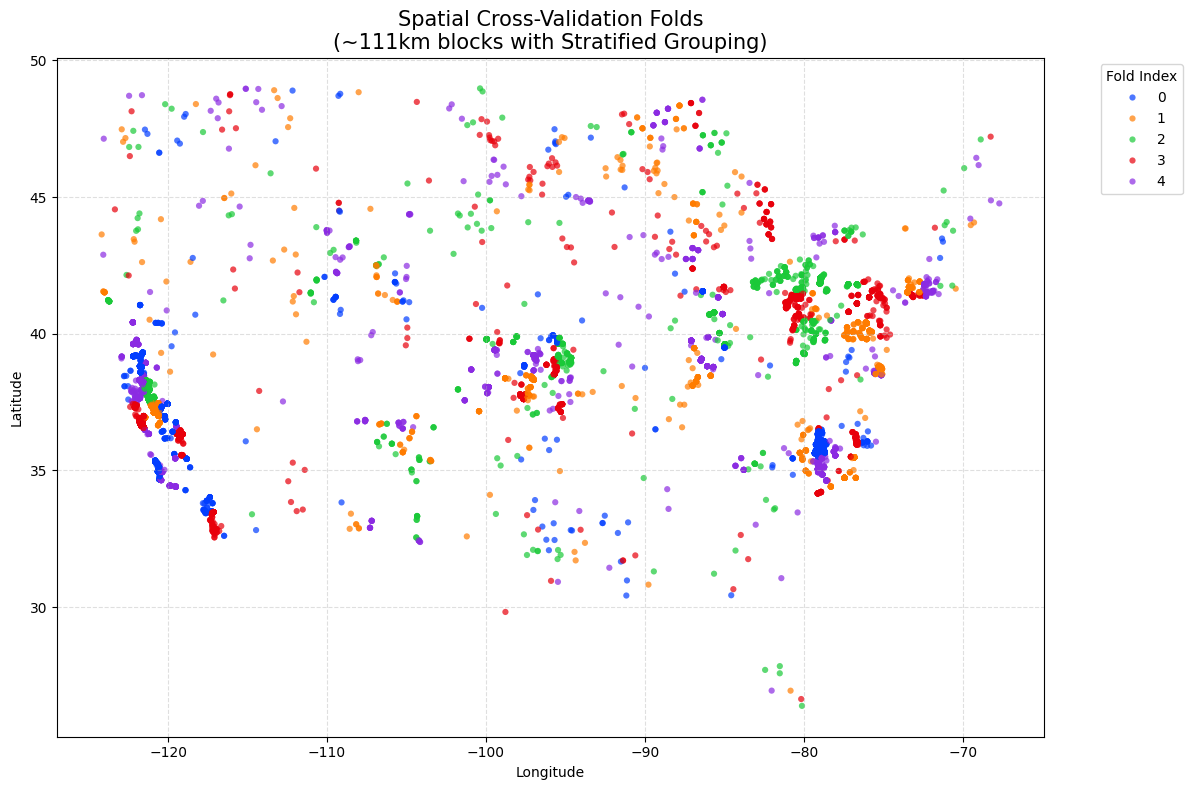

In [198]:
# visualization of folds
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(data=X, x="longitude", y="latitude", hue="fold", palette="bright", s=20, alpha=0.7, edgecolor="none")

plt.title("Spatial Cross-Validation Folds\n(~111km blocks with Stratified Grouping)", fontsize=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Fold Index', bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## XGBoost

In [268]:
# create grid of parameters to test
param_grid_xgb = {
    'max_depth': [3, 4, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'n_estimators': [100, 500, 1000],
}

In [272]:
# create and run search
search_xgb = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=param_grid_xgb,
    n_iter=50, 
    cv=ps,
    scoring='r2',
    verbose=1
)

search_xgb.fit(X_clean, y)

# display results
print(f"best Score: {search_xgb.best_score_}")
print(f"best Params: {search_xgb.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
best Score: 0.5826805733281238
best Params: {'subsample': 0.7, 'n_estimators': 1000, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


In [270]:
results_df = pd.DataFrame(search_xgb.cv_results_)

best_model_idx = search_xgb.best_index_
fold_scores = [results_df.loc[best_model_idx, f'split{i}_test_score'] 
               for i in range(search_xgb.n_splits_)]

print(f"best model's scores for each fold: {np.array(fold_scores)}")

best model's scores for each fold: [0.55470533 0.57596732 0.70141653 0.62232559 0.43613355]


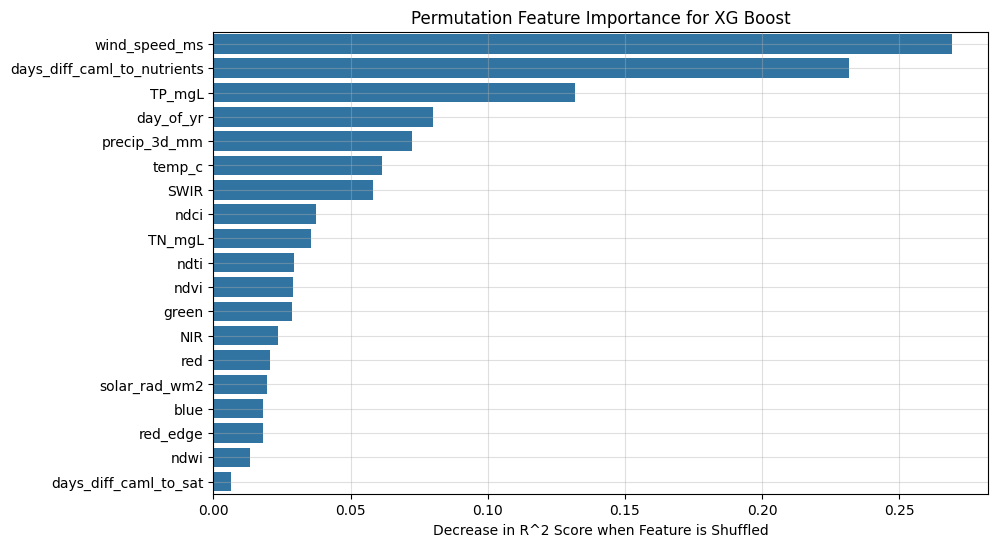

In [271]:
# feature importance plot for best model
xgb = search_xgb.best_estimator_

result = permutation_importance(
    xgb, 
    X_clean, y, 
    n_repeats=10,
    random_state=42, 
    n_jobs=-1
)

feature_importance_rf = pd.DataFrame({
    'feature': X_clean.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_rf.head(20), 
    x='importance_mean',
    y="feature"
)

plt.title("Permutation Feature Importance for XG Boost")
plt.xlabel("Decrease in R^2 Score when Feature is Shuffled")
plt.ylabel("")
plt.grid(alpha=.4)
plt.show()

In [278]:
xgb_rmse = []
for train_idx, test_idx in ps.split():
    X_test, y_test = X_clean.iloc[test_idx], y.iloc[test_idx]
    preds = xgb.predict(X_test)
        
    xgb_rmse.append(np.sqrt(mean_squared_error(y_test, preds)))

print(f"best model's rmse for each fold: {np.array(xgb_rmse)}")
print(f"best model's average rmse: {np.mean(xgb_rmse)}")

best model's rmse for each fold: [0.48071369 0.52124326 0.46533636 0.49121462 0.62425881]
best model's average rmse: 0.5165533474609668


## Random Forest

In [241]:
# create grid of parameters to test
param_grid_rf = {
    'n_estimators': [100, 200, 500],        
    'max_depth': [4, 6, 8, 10],            
    'min_samples_split': [2, 5, 10],       
    'min_samples_leaf': [2, 4, 8],         
    'max_features': ['sqrt', 'log2'],      
    'bootstrap': [True]                 
}

In [242]:
# create and run search
search_rf = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid_rf,
    n_iter=50, 
    cv=ps,
    scoring='r2',
    verbose=1
)

search_rf.fit(X_clean, y)

# display results
print(f"best Score: {search_rf.best_score_}")
print(f"best Params: {search_rf.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
best Score: 0.548229309557559
best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': True}


In [245]:
results_df = pd.DataFrame(search_rf.cv_results_)

best_model_idx = search_rf.best_index_
fold_scores = [results_df.loc[best_model_idx, f'split{i}_test_score'] 
               for i in range(search_rf.n_splits_)]

print(f"best model's scores for each fold: {np.array(fold_scores)}")

best model's scores for each fold: [0.53620645 0.52581844 0.67056332 0.59858716 0.40997118]


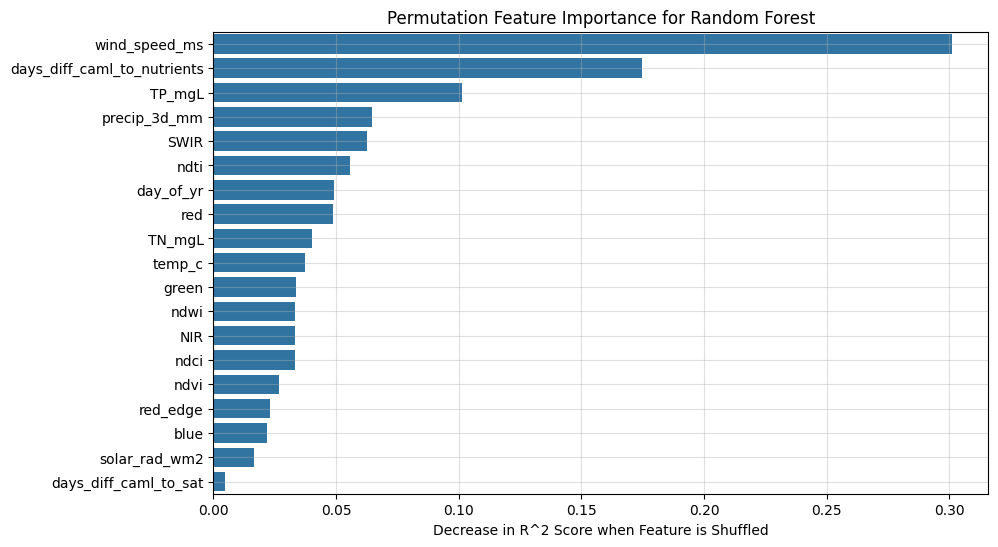

In [266]:
# feature importance plot for best model
rf = search_rf.best_estimator_

result = permutation_importance(
    rf, 
    X_clean, y, 
    n_repeats=10,
    random_state=42, 
    n_jobs=-1
)

feature_importance_rf = pd.DataFrame({
    'feature': X_clean.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_rf.head(20), 
    x='importance_mean',
    y="feature"
)

plt.title("Permutation Feature Importance for Random Forest")
plt.xlabel("Decrease in R^2 Score when Feature is Shuffled")
plt.ylabel("")
plt.grid(alpha=.4)
plt.show()

In [283]:
rf_rmse = []
for train_idx, test_idx in ps.split():
    X_test, y_test = X_clean.iloc[test_idx], y.iloc[test_idx]
    preds = rf.predict(X_test)
        
    rf_rmse.append(np.sqrt(mean_squared_error(y_test, preds)))

print(f"best model's rmse for each fold: {np.array(rf_rmse)}")
print(f"best model's average rmse: {np.mean(rf_rmse)}")

best model's rmse for each fold: [0.54815331 0.62028615 0.53364269 0.58526527 0.71492446]
best model's average rmse: 0.6004543740478876


## Histogram Gradient Boosting Regressor

In [230]:
# create grid of parameters to try
param_grid_hgb = {
    'max_iter': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_regularization': [0, 1, 10, 100]
}

In [ ]:
# create and run search
search_hgb = RandomizedSearchCV(
    estimator=HistGradientBoostingRegressor(random_state=42),
    param_distributions=param_grid_hgb,
    n_iter=50, 
    cv=ps,
    scoring='r2',
    verbose=1
)

search_hgb.fit(X_clean, y)

# display results
print(f"best Score: {search_hgb.best_score_}")
print(f"best Params: {search_hgb.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
best Score: 0.5751301295085808
best Params: {'max_iter': 300, 'max_depth': 7, 'learning_rate': 0.05, 'l2_regularization': 10}


In [ ]:
results_df = pd.DataFrame(search_hgb.cv_results_)

best_model_idx = search_hgb.best_index_
fold_scores = [results_df.loc[best_model_idx, f'split{i}_test_score'] for i in range(search_hgb.n_splits_)]

print(f"best model's scores for each fold: {np.array(fold_scores)}")

best model's scores for each fold: [0.55587871 0.58588784 0.6887234  0.63047634 0.41468436]


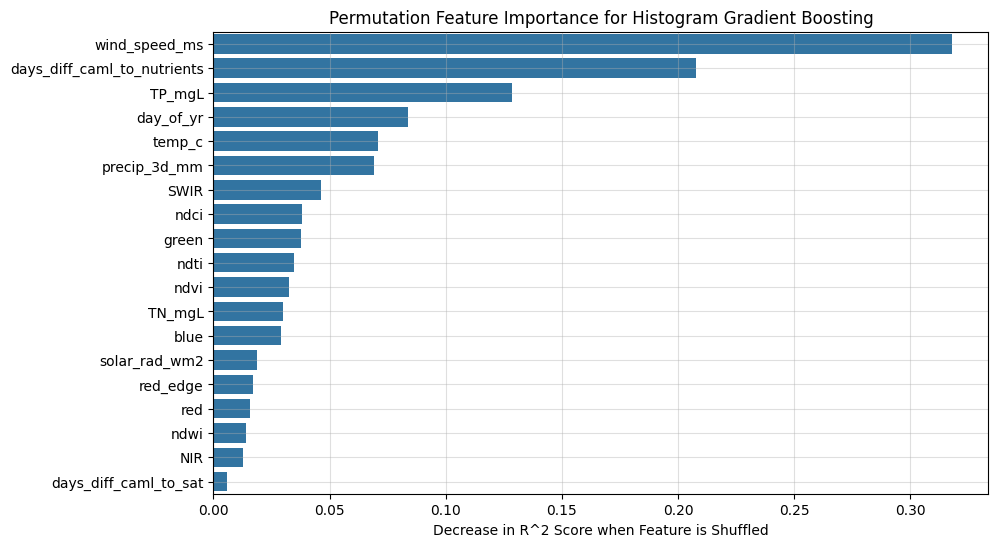

In [ ]:
# feature importance plot for best model
hgb = search_hgb.best_estimator_

result = permutation_importance(
    hgb, 
    X_clean, y, 
    n_repeats=10,
    random_state=42, 
    n_jobs=-1
)

feature_importance_df = pd.DataFrame({
    'feature': X_clean.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df.head(20), 
    x='importance_mean',
    y="feature"
)

plt.title('Permutation Feature Importance for Histogram Gradient Boosting')
plt.xlabel('Decrease in R^2 Score when Feature is Shuffled')
plt.ylabel("")
plt.grid(alpha=.4)
plt.show()

In [284]:
hgb_rmse = []
for train_idx, test_idx in ps.split():
    X_test, y_test = X_clean.iloc[test_idx], y.iloc[test_idx]
    preds = hgb.predict(X_test)
        
    hgb_rmse.append(np.sqrt(mean_squared_error(y_test, preds)))

print(f"best model's rmse for each fold: {np.array(hgb_rmse)}")
print(f"best model's average rmse: {np.mean(hgb_rmse)}")

best model's rmse for each fold: [0.5060222  0.53400025 0.47720071 0.50725938 0.64260487]
best model's average rmse: 0.5334174817401058
